In [74]:
import pandas as pd
import numpy as np
from DPClustX import ClusteringExplainer

In [75]:
dataset_path =  "C:\\Users\\Ronza\\Dev\\DP-Clustering-Explanation\\data\\{ds}\dataset\\{ds}.csv"
cluster_path = 'C:\\Users\\Ronza\\Dev\\DP-Clustering-Explanation\\data\\{ds}\\clustering\\{c}\\{p}\\{ds}_{c}_{p}.csv'

In [82]:
##### Diversity 1/3 0:
# dataset = 'cdc_diabetes'
# method = 'kmeans'
# prep = 'none_scaled'
# num_clusters = 3
# dataset = 'census_1990'
# method = 'kmeans'
# prep = 'none_scaled'
# num_clusters = 3
dataset = 'cdc_diabetes'
method = 'diffpriv_kmeans'
prep = 'none_scaled'
num_clusters = 3

In [83]:
df = pd.read_csv(dataset_path.format(ds=dataset, c=method))
# clusters = pd.read_csv(cluster_path.format(ds=dataset, c=method, p=prep))
clusters = pd.read_csv(cluster_path.format(ds=dataset, c=method, p=prep))
df['cluster'] = clusters[f'{num_clusters}']

In [55]:
df = df[df['class'] == 0]

In [84]:
df[['cluster', 'class']].value_counts()

cluster  class
1        0        110506
0        0         79266
2        0         28562
1        1         21475
2        1         10132
0        1          3739
Name: count, dtype: int64

In [14]:
df = df.loc[:, df.isnull().mean() <= 0.01]

In [60]:
rlabor_mapping = {
    0: 'N/A < 16',
    1: 'Civ Emp,\nAt Work',
    2: ' Civ Emp\nNot At Work',
    3: 'Unemployed',
    4: 'AF, At Work',
    5: ' AF, Not At Work',
    6: 'Not in Labor'
}

yearwrk_mapping = {
0: 'N/A < 16',
1:      '1989-1990',
2:      '1989-1990',
3:      '1988',
4:      '1985-1987',
5:     '1980-1984',
6:     '$\\leq$1979',
# 6:     '(-inf,1979]',
7:     'Never\nWorked'
}

wrk89_mapping = {
0: 'N/A < 16',
1:      'Yes',
2:      'No',
}

means_mapping = {
    0: "Not Worker",
    1: "Car/Truck\n/Van",
    2: "Bus/Tr.Bus",
    3: "Other Method",
    4: "Subway/El.",
    5: "Other Method",
    6: "Other Method",
    7: "Other Method",
    8: "Other Method",
    9: "Other Method",
    10: "Walked",
    11: "At Home",
    12: "Other Method"
}

military_map = {
    0: 'N/A < 16',
    1: "Active Duty Now",
    2: "Past Active Duty",
    3: "Reserves/Nat. Guard",
    4: "No Service"
}

hours_mapping = {
    0: pd.Interval(0, 0, closed='both'),
    1: pd.Interval(1, 30, closed='left'),
    2: pd.Interval(30, 40, closed='left'),
    3: pd.Interval(40, 41, closed='left'),
    4: pd.Interval(41, 50, closed='left'),
    5: pd.Interval(51, right=float('inf'), closed='left'),
}


df['iRlabor'] = df['iRlabor'].apply(lambda x: rlabor_mapping[x])
df['iMeans'] = df['iMeans'].apply(lambda x: means_mapping[x])
df['iYearwrk'] = df['iYearwrk'].apply(lambda x: yearwrk_mapping[x])
df['iWork89'] = df['iWork89'].apply(lambda x: wrk89_mapping[x])
df['dHours'] = df['dHours'].apply(lambda x: hours_mapping[x])
clustered_df = df

KeyError: 'iRlabor'

In [71]:
# clustered_df = clustered_df[['iRlabor','iYearwrk', 'iMeans', 'cluster']]
# del clustered_df['iRemplpar']
clustered_df = df

In [72]:
# explainer.explain(eps_candlist=0.1, eps_topcomb=0.1, eps_hist=0.1)
privacy_budgets = (0.1,0.1,0.1)

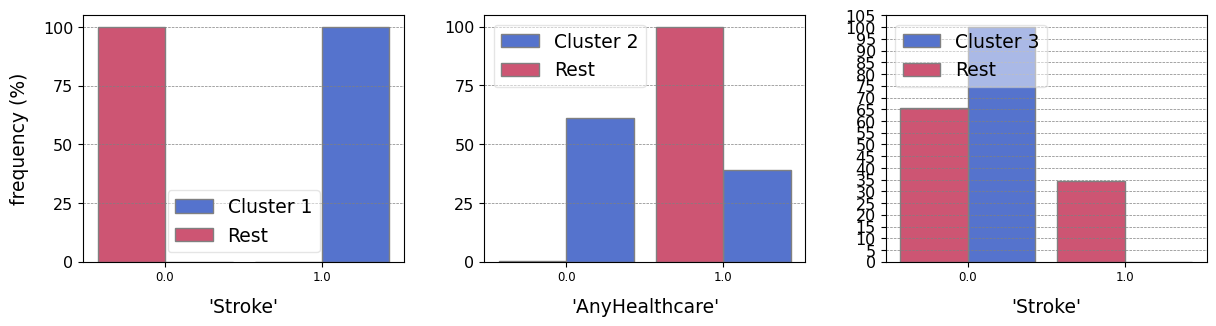

[[0,
  'Stroke',
     bins  counts
  0     0  243388
  1     1   10292,
     bins   counts
  0   0.0      0.0
  1   1.0  10256.0],
 [1,
  'AnyHealthcare',
     bins  counts
  0     0   12417
  1     1  241263,
     bins  counts
  0     0   12041
  1     1    7671],
 [2,
  'Stroke',
     bins  counts
  0     0  243388
  1     1   10292,
     bins    counts
  0   0.0  223712.0
  1   1.0       0.0]]

In [73]:
from DPClustX import ClusteringExplainer
explainer = ClusteringExplainer(clustered_df, diversity_weight=1/3)
explainer.explain(private=False)

In [ ]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:50% !important; }</style>"))

In [44]:
dataset = 'cdc_diabetes'
method = 'kmeans'
prep = 'none_scaled'
num_clusters = 3

In [92]:
df = pd.read_csv(dataset_path.format(ds=dataset, c=method))
# clusters = pd.read_csv(cluster_path.format(ds=dataset, c=method, p=prep))
clusters = pd.read_csv("C:\\Users\Ronza\Dev\DP-Clustering-Explanation\examples\cdc_diabetes_demo_private.csv")
df['cluster'] = clusters[f'{num_clusters}']
clustered_df = df
# clustered_df = clustered_df[['time_in_hospital', 'num_lab_procedures', 'cluster']]

In [93]:
# age_mapping = {
#     1: pd.Interval(18, 24, closed='both'),
#     2: pd.Interval(25, 29, closed='both'),
#     3: pd.Interval(30, 34, closed='both'),
#     4: pd.Interval(35, 39, closed='both'),
#     5: pd.Interval(40, 44, closed='both'),
#     6: pd.Interval(45, 49, closed='both'),
#     7: pd.Interval(50, 54, closed='both'),
#     8: pd.Interval(55, 59, closed='both'),
#     9: pd.Interval(60, 64, closed='both'),
#     10: pd.Interval(65, 69, closed='both'),
#     11: pd.Interval(70, 74, closed='both'),
#     12: pd.Interval(75, 79, closed='both'),
#     13: pd.Interval(80, right=float('inf'), closed='left')
# }

age_mapping = {
    1: pd.Interval(18, 29, closed='both'),
    2: pd.Interval(18, 29, closed='both'),
    3: pd.Interval(30, 39, closed='both'),
    4: pd.Interval(30, 39, closed='both'),
    5: pd.Interval(40, 49, closed='both'),
    6: pd.Interval(40, 49, closed='both'),
    7: pd.Interval(50, 59, closed='both'),
    8: pd.Interval(50, 59, closed='both'),
    9: pd.Interval(60, 69, closed='both'),
    10: pd.Interval(60, 69, closed='both'),
    11: pd.Interval(70, 79, closed='both'),
    12: pd.Interval(70, 79, closed='both'),
    13: pd.Interval(80, right=float('inf'), closed='left')
}

Income_mapping = {
    1: '(0, 10K)',
    2: '[10K, 15K)',
    3: '[15K, 20K)',
    4: '[20K, 25K)',
    5: '[25K, 35K)',
    6: '[35K, 50K)',
    7: '[50K, 75K)',
    8: '[75K, inf)',
}

df['Income'] = df['Income'].apply(lambda x: Income_mapping[x])
clustered_df['Age'] = clustered_df['Age'].apply(lambda x: age_mapping[x])
clustered_df['DiffWalk'] = clustered_df['DiffWalk'].apply(lambda x: 'Yes' if x>0 else 'No')
clustered_df['HighBP'] = clustered_df['HighBP'].apply(lambda x: 'Yes' if x>0 else 'No')
clustered_df['HighChol'] = clustered_df['HighChol'].apply(lambda x: 'Yes' if x>0 else 'No')
# 
# Genhlth_mapping = { 
#     1:  'excellent',
#     2: 'very good',
#     3: 'good',
#     4: 'fair',
#     5: 'poor'
# }
# clustered_df['GenHlth'] = clustered_df['GenHlth'].apply(lambda x: Genhlth_mapping[x])


In [ ]:
# clustered_df = clustered_df[['GenHlth', 'HighBP', 'Age', 'cluster']]

In [ ]:
privacy_budgets = (0.1,0.001,0.1)

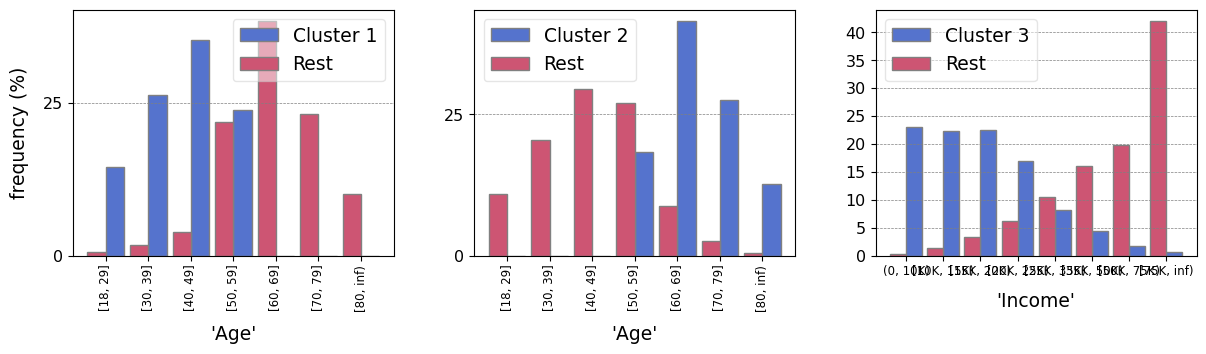

In [116]:
from DPClustX import ClusteringExplainer
explainer = ClusteringExplainer(clustered_df)
explanation = explainer.explain(private=False)

In [117]:
explanation

[[0,
  'Age',
          bins counts
  0   [18, 29]  13298
  1   [30, 39]  24946
  2   [40, 49]  35976
  3   [50, 59]  57146
  4   [60, 69]  65438
  5   [70, 79]  39513
  6  [80, inf)  17363,
          bins   counts
  0   [18, 29]  12114.0
  1   [30, 39]  21865.0
  2   [40, 49]  29274.0
  3   [50, 59]  19752.0
  4   [60, 69]      0.0
  5   [70, 79]      0.0
  6  [80, inf)      0.0],
 [1,
  'Age',
          bins counts
  0   [18, 29]  13298
  1   [30, 39]  24946
  2   [40, 49]  35976
  3   [50, 59]  57146
  4   [60, 69]  65438
  5   [70, 79]  39513
  6  [80, inf)  17363,
          bins   counts
  0   [18, 29]      0.0
  1   [30, 39]      0.0
  2   [40, 49]      0.0
  3   [50, 59]  24163.0
  4   [60, 69]  54741.0
  5   [70, 79]  36338.0
  6  [80, inf)  16739.0],
 [2,
  'Income',
           bins counts
  0    (0, 10K)   9811
  1  [10K, 15K)  11783
  2  [15K, 20K)  15994
  3  [20K, 25K)  20135
  4  [25K, 35K)  25883
  5  [35K, 50K)  36470
  6  [50K, 75K)  43219
  7  [75K, inf)  90385,
     

In [161]:
import textwrap

text_desctiptions = {
    1: " $\\mathbf{'Age'}$ values below $49$ are  $13$ times more frequent in Cluster 1 "
    "($76\\%$) than in the remaining data ($6\\%$).",
    2:  " $\\mathbf{'Age'}$ values above $60$ are  $7$ times more frequent in Cluster 2 "
    "($82\\%$) than in the remaining data ($12\\%$).",
    3:  " $\\mathbf{'Income'}$ values below $25K$ are  $8$ times more frequent in Cluster 3 "
    "($85\\%$) than in the remaining data ($11\\%$)."
}
def wrap_text(text, width=20):
    return "\n".join(textwrap.wrap(text, width))

         Age       Rest  Cluster 1
0   [18, 29]   0.693716  14.594302
1   [30, 39]   1.805185  26.341787
2   [40, 49]   3.926761  35.267755
3   [50, 59]  21.909477  23.796157
4   [60, 69]  38.340706        0.0
5   [70, 79]  23.151018        0.0
6  [80, inf)  10.173136        0.0
         Age       Rest  Cluster 2
0   [18, 29]  10.926959        0.0
1   [30, 39]  20.498114        0.0
2   [40, 49]  29.561459        0.0
3   [50, 59]  27.102113  18.307938
4   [60, 69]   8.789719  41.476425
5   [70, 79]   2.608896  27.532751
6  [80, inf)    0.51274  12.682886
       Income       Rest  Cluster 3
0    (0, 10K)   0.415841  23.044917
1  [10K, 15K)   1.448001  22.406575
2  [15K, 20K)   3.401152  22.437587
3  [20K, 25K)   6.320877  16.917352
4  [25K, 35K)  10.563013   8.202822
5  [35K, 50K)  16.147563   4.535587
6  [50K, 75K)  19.773846   1.829741
7  [75K, inf)  41.929707    0.62542


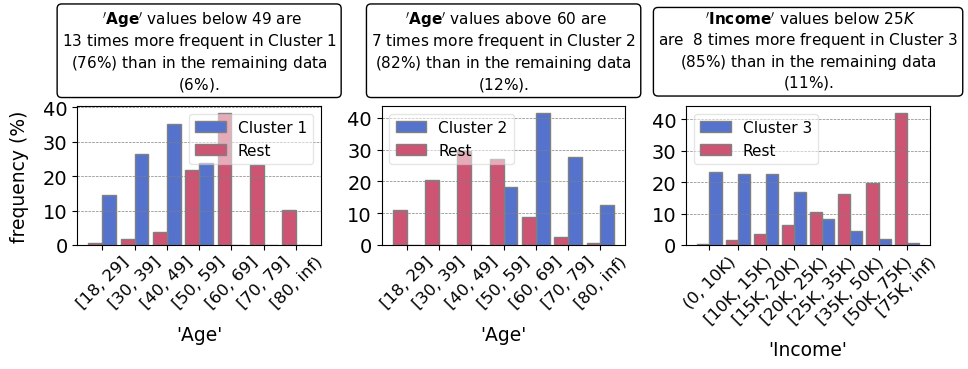

In [164]:
import numpy as np
import pandas as pd
from matplotlib import ticker
import matplotlib.pyplot as plt
from utils import normalize_hist
# Generate data and store it in the list
data = []

# Generate data and store it in the list
for c, attr, hist_all, hist_cluster in explanation:
    no_clust_label = 'Dataset'
    ylabel = 'Count'
    hist_rest = hist_all.copy()
    if True:
        no_clust_label = 'Rest'
        hist_rest['counts'] = hist_rest['counts'] - hist_cluster['counts']
        hist_rest.loc[hist_rest['counts'] <= 0, 'counts'] = 0
    if True:
        hist_rest = normalize_hist(hist_rest)
        hist_cluster = normalize_hist(hist_cluster)
        ylabel = 'frequency (%)'

    hist_rest = pd.DataFrame(hist_rest, columns=[attr, no_clust_label])
    hist_cluster = pd.DataFrame(hist_cluster, columns=[attr, f'Cluster {c + 1}'])
    plot_df = pd.merge(hist_rest, hist_cluster)
    plot_df = plot_df[plot_df[no_clust_label] + plot_df[f'Cluster {c + 1}'] > 3]
    print(plot_df)
    # Store the data and labels
    data.append({
        'plot_df': plot_df,
        'no_clust_label': no_clust_label,
        'cluster_label': f'Cluster {c + 1}',
        'ylabel': ylabel,
        'attr': attr
    })
# fig = plt.figure(figsize=(20, 6.2)) # For opt
fig = plt.figure(figsize=(11, 1.8))  # For DP
plt.subplots_adjust(hspace=0.25, wspace=0.25)
# create 3x1 subfigs

axs = fig.subplots(nrows=1, ncols=len(explanation))

axs = axs.flatten()
j = 0
for ax, dat in zip(axs, data):
    plot_df = dat['plot_df']
    bar_width = 0.43  # Adjust bar width
    r1 = np.arange(len(plot_df[dat['attr']]))
    r2 = [x + bar_width for x in r1]

    ax.bar(r2, plot_df[dat['cluster_label']], width=bar_width, edgecolor='grey', label=dat['cluster_label'],
           color='#5573CD')
    ax.bar(r1, plot_df[dat['no_clust_label']], width=bar_width, edgecolor='grey', label=dat['no_clust_label'],
           color='#CD5573')

    ax.set_xlabel(f"'{dat['attr']}'", fontsize=13.5, labelpad=10)  # Increase font size
    ax.set_xticks([r + bar_width / 2 for r in r1])
    if dat['attr'] == 'GenHlth':
        rotate = 45
    elif dat['attr'] == 'Age':
        rotate = 45
    else:
        rotate = 45

    ax.set_xticklabels(plot_df[dat['attr']], rotation=rotate, ha='center')  # Rotate and align text

    if dat['attr'] == 'GenHlth':
        ax.set_xticklabels(['Excellent', 'Very good', 'Good', 'Fair', 'Poor'])

    ax.tick_params(axis='both', which='major', labelsize=14)  # Increase font size
    ax.tick_params(axis='x', which='major', pad=2.5, labelsize=12)
    if j == 0:
        ax.set_ylabel(dat['ylabel'], fontsize=13.5, labelpad=10)  # Increase font size
    ax.yaxis.set_major_locator(ticker.MultipleLocator(base=25))
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', axis='y')
    # ax.legend(fontsize=20)  # Increase legend font size

    if j == 2:
        ax.legend(loc='upper left', fontsize=11, framealpha=0.5)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10))
        # ax.legend(loc='best',fontsize=8, framealpha=0.5)
        # ax.legend(fontsize=22)
    else:
        ax.legend(loc='best', fontsize=11, framealpha=0.5)
        # ax.legend(fontsize=26, framealpha=0.7)
    if dat['attr'] == 'Age':
        ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10))
    
    wrapped = wrap_text(text_desctiptions[j+1], 41)
    ax.text(
        0.5, 1.4, wrapped,  # x, y position (relative to the axes)
        transform=ax.transAxes,  # Use axis coordinates for positioning
        fontsize=11, 
        ha='center',  # Horizontal alignment
        va='center',  # Vertical alignment
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white')  # Bounding box style
    )
    j += 1
# plt.tight_layout()
plt.show() 

In [136]:
0.415841+  1.448001+  3.401152+ 6.320877

11.585871000000001

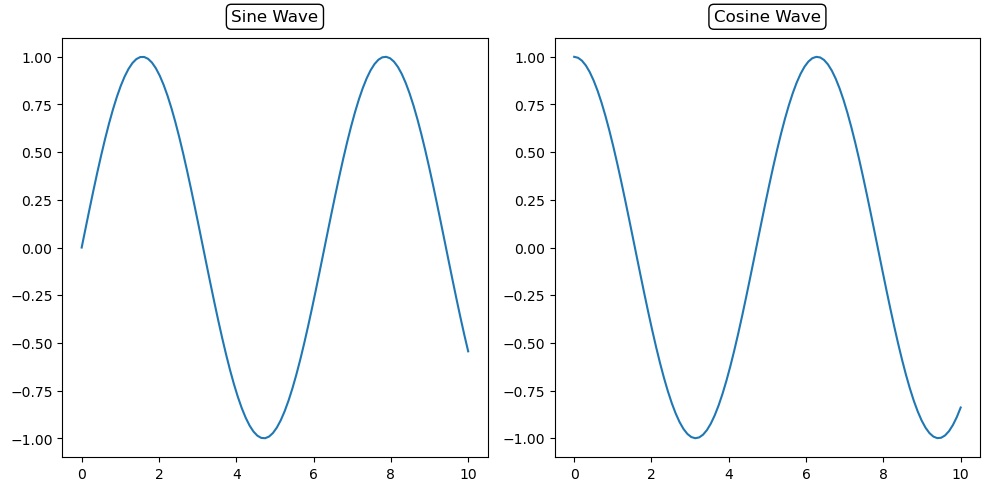

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot data
axes[0].plot(x, y1)
axes[1].plot(x, y2)

# Add framed text above each subplot
titles = ['Sine Wave', 'Cosine Wave']
for ax, title in zip(axes, titles):
    ax.text(
        0.5, 1.05, title,  # x, y position (relative to the axes)
        transform=ax.transAxes,  # Use axis coordinates for positioning
        fontsize=12, 
        ha='center',  # Horizontal alignment
        va='center',  # Vertical alignment
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white')  # Bounding box style
    )

# Adjust layout
plt.tight_layout()
plt.show()


In [134]:
df['Income'].value_counts()

Income
[75K, inf)    90385
[50K, 75K)    43219
[35K, 50K)    36470
[25K, 35K)    25883
[20K, 25K)    20135
[15K, 20K)    15994
[10K, 15K)    11783
(0, 10K)       9811
Name: count, dtype: int64